In [2]:
!echo $LD_LIBRARY_PATH, $CONDA_PREFIX

/hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib, /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm


In [3]:
import pyccl as ccl
import numpy as np
from scipy.integrate import simpson
import matplotlib.pyplot as plt

In [4]:
import matplotlib as mpl

mpl.use("Agg")
mpl.rcParams["font.size"] = 16
mpl.rcParams["text.usetex"] = "True"

In [5]:
cosmo = ccl.CosmologyVanillaLCDM()

# Here we use a mass definition with Delta = 200 times the matter density,
# Note: We are defining mass w.r.t the matter density, not the critical density, which is more common in some contexts.
# keep in mind when instantiating base cl.halos.HaloProfileHOD class with mass_def and concentration-mass relation, as both should follow same rho_type convention.
# If they differ, cl.halos.HaloProfileHOD will raise an error, which is good to prevent mistakes.
hmd_200m = ccl.halos.MassDef200m
# The Duffy2008 concentration-mass relation, by default it will be initialized for S.O masses with Delta=Delta_vir of Delta_vir=200
# critical density based halo mass :math:`M_{200c}`.  (Evolution of Mvir (SO based mass even when Delta is fixed to 200) with redshift is shown below.)
cM = ccl.halos.ConcentrationDuffy08(mass_def=hmd_200m)
assert cM.mass_def == hmd_200m, "This is what you've to be careful of!"
assert cM.mass_def.name == hmd_200m.name, "Same issue"

In [6]:
hmd_200m?

Type:        MassDef
String form: MassDef(Delta=200, rho_type=matter)
File:        /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/massdef.py
Docstring:  
Halo mass definition. Halo masses are defined in terms of an overdensity
parameter :math:`\Delta` and an associated density :math:`X` (either the
matter density or the critical density):

.. math::
    M_\Delta = \frac{4 \pi}{3} \Delta\,\rho_X\, R_\Delta^3

where :math:`R_\Delta` is the halo radius. This object also holds methods
to translate between :math:`R_\Delta` and :math:`M_\Delta`, and to
translate masses between different definitions if a concentration-mass
relation is provided.

You may also define halo masses based on a Friends-of-Friends algorithm,
in which case simply pass ``Delta='fof'`` below.

Args:
    Delta (:obj:`float`): overdensity parameter. Pass ``'vir'`` if using virial
        overdensity. Pass ``'fof'`` for Friends-of-Friends halos.
    rho_type (:obj:`str`): either

### How the $M_{vir}$ changes with redshift even if you keep the $\Delta=200$ fixed.

In [7]:
mpl.use("inline")
%matplotlib inline

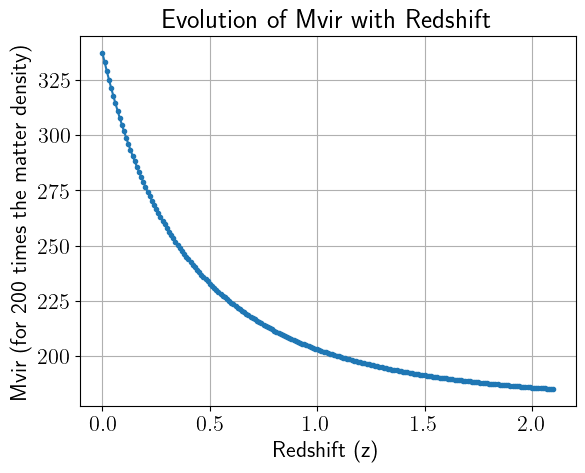

In [8]:
# Checking how Mvir evolves with redshift for this cosmology and fixed mass definition of 200 times the matter density.
z = np.linspace(0, 2.1, 211)
aa = 1 / (1 + z)
mvir = []
for a in aa:
    mvir.append(hmd_200m.get_Delta_vir(cosmo, a))

plt.cla()
plt.plot(z, mvir, ".-")
plt.xlabel("Redshift (z)")
plt.ylabel("Mvir (for 200 times the matter density)")
plt.title("Evolution of Mvir with Redshift")
plt.grid()
# plt.savefig("Mvir_vs_scaleFactor_for_M200m_mass_def.png", bbox_inches='tight', dpi=200)
plt.show()

In [9]:
ccl.halos.HaloProfileHOD?

Init signature:
ccl.halos.HaloProfileHOD(
    self,
    *,
    mass_def,
    concentration,
    log10Mmin_0=12.0,
    log10Mmin_p=0.0,
    siglnM_0=0.4,
    siglnM_p=0.0,
    log10M0_0=7.0,
    log10M0_p=0.0,
    log10M1_0=13.3,
    log10M1_p=0.0,
    alpha_0=1.0,
    alpha_p=0.0,
    fc_0=1.0,
    fc_p=0.0,
    bg_0=1.0,
    bg_p=0.0,
    bmax_0=1.0,
    bmax_p=0.0,
    a_pivot=1.0,
    ns_independent=False,
    is_number_counts=True,
)
Docstring:     
A generic halo occupation distribution (HOD)
profile describing the number density of galaxies
as a function of halo mass.

The parametrization for the mean profile is:

.. math::
   \langle n_g(r)|M,a\rangle = \bar{N}_c(M,a)
   \left[f_c(a)+\bar{N}_s(M,a) u_{\rm sat}(r|M,a)\right]

where :math:`\bar{N}_c` and :math:`\bar{N}_s` are the
mean number of central and satellite galaxies respectively,
:math:`f_c` is the observed fraction of central galaxies, and
:math:`u_{\rm sat}(r|M,a)` is the distribution of satellites
as a function of dist

In [10]:
ccl.halos.halo_model.HMCalculator.integrate_over_massfunc?

Signature:
ccl.halos.halo_model.HMCalculator.integrate_over_massfunc(
    self,
    func,
    cosmo,
    a,
)
Docstring:
Returns the integral over mass of a given funcion times
the mass function:

.. math::
    \int dM\,n(M,a)\,f(M)

Args:
    func (:obj:`callable`): a function accepting an array of halo masses
        as a single argument, and returning an array of the
        same size.
    cosmo (:class:`~pyccl.cosmology.Cosmology`): a Cosmology object.
    a (:obj:`float`): scale factor.

Returns:
    :obj:`float`: integral value.
File:      /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/halo_model.py
Type:      function

### Zecharegkas and Chang et al 2026 HOD model 

In [11]:
from typing import Union, Optional


class CacciatoHOD(ccl.halos.HaloProfileHOD):
    def __init__(
        self,
        *,
        mass_def: Union[str, ccl.halos.MassDef],
        cM_rel: Union[str, ccl.halos.Concentration],
        Lmin,
        Lmax,
        N_L=64,
        log_L0=9.95,
        lM_1=11.24,
        gamma_1=3.18,
        gamma_2=0.245,
        sigma_c=0.157,
        alpha_s=-1.18,
        b_0=-1.17,
        b_1=1.53 * 0.739,
        b_2=-0.217 * 0.739**2,
        fh=1.0,
        fs=1.0,
    ) -> None:
        """
        Custom HOD model based on Cacciato et al.

        Args:
            mass_def: Halo mass definition (e.g., '200m' or a MassDef object).
            cM_rel: Concentration-mass relation (e.g., 'Duffy08' or a Concentration object).
            **kwargs: Additional HOD parameters passed to the parent class.
        """
        # Initialize the parent class with essential parameters
        # overwrite more parent attr if you need.
        super().__init__(mass_def=mass_def, concentration=cM_rel)

        # fh, fs the scaling of cM_rel, to be include in _usat_real/fourier
        # b_1 and b_2 have been rescaled by h from Cacciato et al. 2013
        self.cM = cM_rel


In [12]:
# test vectorization
@np.vectorize(excluded=["x"])
def test(x, y):
    return x * 2, y * 3


print(test(3, np.arange(4)))


(array([6, 6, 6, 6]), array([0, 3, 6, 9]))


In [13]:
from scipy.special import gammaincc, gamma


@np.vectorize(excluded=["a"])
def safe_upper_gamma(a, x):
    """
    Computes the upper incomplete gamma function Γ(a, x) for any real 'a'.
    Uses the recurrence relation to handle negative 'a' values.

    Parameters:
        a (float): The shape parameter, can be any real number.
        x (float): The upper/lower limit of lower/upper-gamma function integration, must be non-negative.
    Returns:
        float: The value of the upper incomplete gamma function Γ(a, x).
    """
    # Base case: x is 0 and a <= 0, the integral diverges
    if x <= 0 and a <= 0:
        return np.inf

    # Base case: a is positive, use standard scipy
    if a > 0:
        return gammaincc(a, x) * gamma(a)

    # Recurrence relation: Γ(a, x) = (Γ(a+1, x) - x^a * e^-x) / a
    # This shifts 'a' upward until it hits the positive base case
    return (safe_upper_gamma(a + 1, x) - x**a * np.exp(-x)) / a

In [14]:
# actual parameters
cacciato_med_pars = dict(
    log_L0=9.95,
    log_M1=11.24,
    gamma_1=3.18,
    gamma_2=0.245,
    sigma_c=0.157,
    alpha_s=-1.18,
    b_0=-1.17,
    b_1=1.53,
    b_2=-0.217,
)

# sample information from cacciato et al. 2013, table 1, for the 6 luminosity bins defined by the magnitude cuts in their paper.
# the brighter edge of each magnitude is excluded, so the bins are defined as ( mag_bins[0][0], mag_bins[0][1] ], ...
mag_edges = np.linspace(-23, -17, 7)
mag_bins = np.array(list(zip(mag_edges[:-1], mag_edges[1:])))

print("Cacciato et al. 2013 luminosity bins defined by magnitude cuts:")
for i in range(len(mag_bins)):
    print(f"magnitude bins ({mag_bins[i][0]}, {mag_bins[i][1]}]")

sampleinfo = dict(
    mag_bins=mag_bins,
    zmins=np.array([0.011, 0.017, 0.027, 0.042, 0.066, 0.103]),
    zmaxs=np.array([0.026, 0.042, 0.064, 0.106, 0.159, 0.245]),
    zmeans=np.array([0.021, 0.032, 0.050, 0.082, 0.123, 0.187]),
)

# one used by Christos, with b_1 and b_2 rescaled by h=0.739
# I'm keeping this only to compare my HOD plots from his.
christos_pars = dict(
    log_L1=np.log10(1.5e7),
    log_L2=np.log10(5.6e9),
    log_L0=9.95,
    log_M1=11.24,
    gamma_1=3.18,
    gamma_2=0.245,
    sigma_c=0.157,
    alpha_s=-1.18,
    b_0=-1.17,
    b_1=1.53 * 0.739,
    b_2=-0.217 * 0.739**2,
)


def magnitude_to_luminosity(M, M_ref=4.76):
    """
    Converts absolute AB magnitude M (K+E corrected to z=0.1) to solar luminosities
    L/L_ref.  Here L_ref is the Absolute Solar-Magnitude in the band of interest
    in the AB magnitude system. For the r-band, M_ref=4.76 is the absolute
    magnitude of the reference source (Sun), which is commonly used as a
    reference for luminosity calculations. (see Blanton et al 2003, eq 14.)

    We use this function when the lens subsamples are defined on absolute
    magnitudes rather than luminosities. The HOD model is defined in terms of
    luminosity, so we need to convert the magnitude cuts to luminosity cuts
    before computing the occupation numbers.

    Note:
        The formula is derived from the definition of absolute magnitude and luminosity:
        M = M_ref - 2.5 * log10(L / L_ref)
        Rearranging gives:
        L / L_ref = 10^((M_ref - M) / 2.5) = 10^(0.4 * (M_ref - M))

        Depending on the band and the specific K+E corrections applied, the
        value of M_ref may need to be adjusted.  This function assumes M_ref = 4.76,
        which is a common value for the r-band. Adjust M_ref as needed for other
        bands or corrections.
    """
    return 10 ** (0.4 * (M_ref - M))


Cacciato et al. 2013 luminosity bins defined by magnitude cuts:
magnitude bins (-23.0, -22.0]
magnitude bins (-22.0, -21.0]
magnitude bins (-21.0, -20.0]
magnitude bins (-20.0, -19.0]
magnitude bins (-19.0, -18.0]
magnitude bins (-18.0, -17.0]


### CSMF model

In [15]:
from typing import Union, Optional
from scipy.special import erf

# class CacciatoHOD(ccl.halos.HaloProfileHOD):
#     def __init__(self, *,
#                  mass_def: Union[str, ccl.halos.MassDef],
#                  cM_rel: Union[str, ccl.halos.Concentration],
#                  log_L1, log_L2,
#                  log_L0=9.95, log_M1=11.24,
#                  gamma_1=3.18, gamma_2=0.245,
#                  sigma_c=0.157, alpha_s=-1.18,
#                  b_0=-1.17, b_1=1.53, b_2=-0.217,
#                  ) -> None:
#         """
#         HOD model based on Cacciato et al. (2013) has 9 free parameters as listed below:
#         - log_L0: log10 of the normalization factor (L0) of the central galaxy
#             luminosity function L_c(M) as a function of halo mass. Here the central
#             galaxies are those that belong in the sample we're modeling.
#         - log_M1: log10 of the characteristic halo mass scale (M1).
#         - gamma_1: slope of the central galaxy luminosity function at the low-mass end (M << M1).
#         - gamma_2: slope of the central galaxy luminosity function at the high-mass end (M >> M1).
#         - sigma_c: scatter in the luminosities of central galaxies in the sample
#             populating a fixed halo mass, M.
#         - alpha_s: faint end of the slope of the satellite galaxy occupation
#             number. Independent of (M,z), can be changed.
#         - b_0, b_1, b_2: parameters for the satellite galaxy luminosity function.

#         Args:
#             mass_def: Halo mass definition (e.g., '200m' or a MassDef object).
#             cM_rel: Concentration-mass relation (e.g., 'Duffy08' or a Concentration object).
#             log_L1, log_L2: luminosity bin of the lens sample we're modeling in log10.
#             log_L0, log_M1, gamma_1, gamma_2, sigma_c, alpha_s, b_0, b_1, b_2:
#                 Free parameters of the CLF model, as described above.
#         """
#         # Initialize the parent class with essential parameters
#         # overwrite more parent attr if you need.
#         super().__init__(mass_def=mass_def, concentration=cM_rel)

#         # fh, fs the scaling of cM_rel, to be include in _usat_real/fourier
#         # b_1 and b_2 have been rescaled by h from Cacciato et al. 2013
#         self.cM = cM_rel

#         # sample luminosity range
#         self.log_L1 = log_L1
#         self.log_L2 = log_L2
#         # CLF free parameters
#         self.log_L0 = log_L0
#         self.log_M1 = log_M1
#         self.gamma_1 = gamma_1
#         self.gamma_2 = gamma_2
#         self.sigma_c = sigma_c
#         self.alpha_s = alpha_s # independent of halo mass in this work, but can be made mass dependent if needed.
#         self.b_0 = b_0
#         self.b_1 = b_1
#         self.b_2 = b_2
#         #constants
#         self.loge = np.log10(np.e)

#     def _log_Lc(self, logM):
#         """Characteristic luminosity of central galaxies in the sample as a
#         function of halo mass."""
#         return self.log_L0 + self.gamma_1 *(logM - self.log_M1) - \
#                (self.gamma_1 - self.gamma_2) * np.log10(1 + 10**(logM-self.log_M1))

#     def _log_L_star_s(self, logM):
#         """Characteristic luminosity of satellite galaxies in the sample as a
#         function of halo mass."""
#         return np.log10(0.562) + self._log_Lc(logM)

#     def _log_phi_star_s(self, logM):
#         """The ingredients, M_12, b_0, b_1, b_2, are unitless and required to
#         compute the normalization of the satellite CLF.  None of these are
#         physically motivated, but they are just fitting functions to the CLF of
#         Yang et al 2008 and then in Cacciato et al. 2013."""
#         logM12 = logM - 12 # CCL convension: Solar mass, not h^-1 Solar mass, so no need to include h here.
#         log_phi_star_s = self.b_0 + self.b_1 * logM12 + self.b_2 * logM12**2
#         return log_phi_star_s

#     def _Nc(self, logM): # ---check math
#         """Overried the parent method to compute the mean occupation number of
#         central galaxies in the sample, which is the integral of Phi_c(L|M) over
#         the luminosity range of the sample."""
#         logLc = self._log_Lc(logM)
#         # Standardized variables for the erf function
#         denom = np.sqrt(2) * self.sigma_c
#         term_max = (self.log_L2 - logLc) / denom
#         term_min = (self.log_L1 - logLc) / denom

#         return 0.5 * (erf(term_max) - erf(term_min))

#     def _Ns(self, logM): # ------ check math
#         phi_star_s = 10**self._log_phi_star_s(logM)
#         logLs = self._log_L_star_s(logM)

#         # The exponent for the Gamma function
#         # Note: (alpha + 1) / 2
#         shape = (self.alpha_s + 1) / 2.0

#         # Limits for the integral
#         # Incomplete Gamma integrated from x to infinity
#         x_min = 2.0*(self.log_L1 - logLs)
#         x_max = 2.0*(self.log_L2 - logLs)

#         # gammaincc is the regularized form: Gamma(a, x) / Gamma(a)
#         # So we multiply by gamma(shape) to get the actual integral value
#         integral_min = safe_upper_gamma(shape, 10**x_min)
#         integral_max = safe_upper_gamma(shape, 10**x_max)

#         return (phi_star_s / 2.0) * (integral_min - integral_max)


class CacciatoHOD(ccl.halos.HaloProfileHOD):
    def __init__(
        self,
        *,
        mass_def: Union[str, ccl.halos.MassDef],
        cM_rel: Union[str, ccl.halos.Concentration],
        log_L1,
        log_L2,
        log_L0=9.95,
        log_M1=11.24,
        gamma_1=3.18,
        gamma_2=0.245,
        sigma_c=0.157,
        alpha_s=-1.18,
        b_0=-1.17,
        b_1=1.53,
        b_2=-0.217,
    ) -> None:
        """
        HOD model based on Cacciato et al. (2013) has 9 free parameters as listed below:
        - log_L1, log_L2: luminosity bin of the lens sample we're modeling in log10. (log_L2>log_L1)
        - log_L0: log10 of the normalization factor (L0) of the central galaxy
            luminosity function L_c(M) as a function of halo mass. Here the central
            galaxies are those that belong in the sample we're modeling.
        - log_M1: log10 of the characteristic halo mass scale (M1).
        - gamma_1: slope of the central galaxy luminosity function at the low-mass end (M << M1).
        - gamma_2: slope of the central galaxy luminosity function at the high-mass end (M >> M1).
        - sigma_c: scatter in the luminosities of central galaxies in the sample
            populating a fixed halo mass, M.
        - alpha_s: faint end of the slope of the satellite galaxy occupation
            number. Independent of (M,z), can be changed.
        - b_0, b_1, b_2: parameters for the satellite galaxy luminosity function.

        Args:
            mass_def: Halo mass definition (e.g., '200m' or a MassDef object).
            cM_rel: Concentration-mass relation (e.g., 'Duffy08' or a Concentration object).
            log_L1, log_L2: luminosity bin of the lens sample we're modeling in log10.
            log_L0, log_M1, gamma_1, gamma_2, sigma_c, alpha_s, b_0, b_1, b_2:
                Free parameters of the CLF model, as described above.
        """
        # Initialize the parent class with essential parameters
        # overwrite more parent attr if you need.
        super().__init__(mass_def=mass_def, concentration=cM_rel)

        # fh, fs the scaling of cM_rel, to be include in _usat_real/fourier
        # b_1 and b_2 have been rescaled by h from Cacciato et al. 2013
        self.cM = cM_rel

        # sample luminosity range
        self.log_L1 = log_L1
        self.log_L2 = log_L2
        # CLF free parameters
        self.log_L0 = log_L0
        self.log_M1 = log_M1
        self.gamma_1 = gamma_1
        self.gamma_2 = gamma_2
        self.sigma_c = sigma_c
        self.alpha_s = alpha_s  # independent of halo mass in this work, but can be made mass dependent if needed.
        self.b_0 = b_0
        self.b_1 = b_1
        self.b_2 = b_2
        # constants
        self.loge = np.log10(np.e)

    def _log_Lc(self, M):
        """Characteristic luminosity of central galaxies in the sample as a
        function of halo mass."""
        return (
            self.log_L0
            + self.gamma_1 * (np.log10(M) - self.log_M1)
            - (self.gamma_1 - self.gamma_2) * np.log10(1 + M / 10**self.log_M1)
        )

    def _log_L_star_s(self, M):
        """Characteristic luminosity of satellite galaxies in the sample as a
        function of halo mass."""
        return np.log10(0.562) + self._log_Lc(M)

    def _log_phi_star_s(self, M):
        """The ingredients, M_12, b_0, b_1, b_2, are unitless and required to
        compute the normalization of the satellite CLF.  None of these are
        physically motivated, but they are just fitting functions to the CLF of
        Yang et al 2008 and then in Cacciato et al. 2013."""
        logM12 = (
            np.log10(M) - 12
        )  # CCL convension: Solar mass, not h^-1 Solar mass, so no need to include h here.
        log_phi_star_s = self.b_0 + self.b_1 * logM12 + self.b_2 * logM12**2
        return log_phi_star_s

    def _Nc(self, M):  # ---check math
        """Overried the parent method to compute the mean occupation number of
        central galaxies in the sample, which is the integral of Phi_c(L|M) over
        the luminosity range of the sample."""
        logLc = self._log_Lc(M)
        # Standardized variables for the erf function
        denom = np.sqrt(2) * self.sigma_c
        term_max = (self.log_L2 - logLc) / denom
        term_min = (self.log_L1 - logLc) / denom

        return 0.5 * (erf(term_max) - erf(term_min))

    def _Ns(self, M):  # ------ check math
        phi_star_s = 10 ** self._log_phi_star_s(M)
        logLs = self._log_L_star_s(M)

        # The exponent for the Gamma function
        # Note: (alpha + 1) / 2
        shape = (self.alpha_s + 1) / 2.0

        # Limits for the integral
        # Incomplete Gamma integrated from x to infinity
        x_min = 2.0 * (self.log_L1 - logLs)
        x_max = 2.0 * (self.log_L2 - logLs)

        # gammaincc is the regularized form: Gamma(a, x) / Gamma(a)
        # So we multiply by gamma(shape) to get the actual integral value
        integral_min = safe_upper_gamma(shape, 10**x_min)
        integral_max = safe_upper_gamma(shape, 10**x_max)
        return (phi_star_s / 2.0) * (integral_min - integral_max)


In [16]:
bright, faint = sampleinfo["mag_bins"][0]
log_L1 = np.log10(magnitude_to_luminosity(faint))
log_L2 = np.log10(magnitude_to_luminosity(bright))

print(
    f"Cacciato+2008: luminosity bin for the first magnitude bin {sampleinfo['mag_bins'][0]}:"
)
print(f"{log_L1:<.4e}, {log_L2:<.4e}")

Cacciato+2008: luminosity bin for the first magnitude bin [-23. -22.]:
1.0704e+01, 1.1104e+01


In [17]:
my_params = dict(log_L1=log_L1, log_L2=log_L2, **cacciato_med_pars)
print(my_params, cacciato_med_pars, sep="\n\n")

{'log_L1': np.float64(10.704), 'log_L2': np.float64(11.104), 'log_L0': 9.95, 'log_M1': 11.24, 'gamma_1': 3.18, 'gamma_2': 0.245, 'sigma_c': 0.157, 'alpha_s': -1.18, 'b_0': -1.17, 'b_1': 1.53, 'b_2': -0.217}

{'log_L0': 9.95, 'log_M1': 11.24, 'gamma_1': 3.18, 'gamma_2': 0.245, 'sigma_c': 0.157, 'alpha_s': -1.18, 'b_0': -1.17, 'b_1': 1.53, 'b_2': -0.217}


In [18]:
my_params

{'log_L1': np.float64(10.704),
 'log_L2': np.float64(11.104),
 'log_L0': 9.95,
 'log_M1': 11.24,
 'gamma_1': 3.18,
 'gamma_2': 0.245,
 'sigma_c': 0.157,
 'alpha_s': -1.18,
 'b_0': -1.17,
 'b_1': 1.53,
 'b_2': -0.217}

In [19]:
np.linspace(8, 16, 33)

array([ 8.  ,  8.25,  8.5 ,  8.75,  9.  ,  9.25,  9.5 ,  9.75, 10.  ,
       10.25, 10.5 , 10.75, 11.  , 11.25, 11.5 , 11.75, 12.  , 12.25,
       12.5 , 12.75, 13.  , 13.25, 13.5 , 13.75, 14.  , 14.25, 14.5 ,
       14.75, 15.  , 15.25, 15.5 , 15.75, 16.  ])

In [20]:
hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, **my_params)
# # logM = np.linspace(8,16,128)
# Ns = hod._Ns(logM)
# Nc = hod._Nc(logM)
M = np.geomspace(10**8, 10**16, 33)
Ns = hod._Ns(M)
Nc = hod._Nc(M)

In [21]:
Ns

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 2.70843392e-126,
       1.47730364e-052, 3.04922313e-028, 8.50452642e-018, 2.68365942e-012,
       6.16113040e-009, 1.16635258e-006, 5.21312938e-005, 9.21782202e-004,
       8.55706219e-003, 4.94677562e-002, 1.98993708e-001, 6.01162601e-001,
       1.43996769e+000, 2.84444977e+000, 4.76689984e+000, 6.91429398e+000,
       8.80337009e+000])

<>:9: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:9: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_3315148/1362277693.py:9: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax.set_xlabel("$M$ [M$_\odot$]")


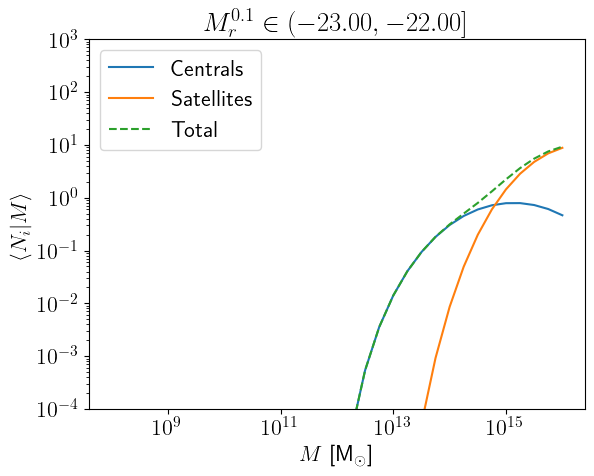

In [25]:
fig, ax = plt.subplots()
ax.loglog(M, Nc, label="Centrals")
ax.loglog(M, Ns, label="Satellites")
ax.loglog(M, Nc + Ns, "--", label="Total")
# ax.loglog(10**logM, Nc, label='Centrals')
# ax.loglog(10**logM, Ns, label='Satellites')
ax.set_ylim(1e-4, 1e3)
ax.legend()
ax.set_xlabel("$M$ [M$_\odot$]")
ax.set_ylabel(r"$\langle N_i|M \rangle$")
ax.set_title(rf"$M_{{r}}^{{0.1}}\in({bright:.2f},{faint:.2f}]$")
# plt.savefig("Cacciato_HOD_Nc_Ns_vs_M.pdf", bbox_inches='tight', dpi=200)
plt.show()

In [26]:
sampleinfo

{'mag_bins': array([[-23., -22.],
        [-22., -21.],
        [-21., -20.],
        [-20., -19.],
        [-19., -18.],
        [-18., -17.]]),
 'zmins': array([0.011, 0.017, 0.027, 0.042, 0.066, 0.103]),
 'zmaxs': array([0.026, 0.042, 0.064, 0.106, 0.159, 0.245]),
 'zmeans': array([0.021, 0.032, 0.05 , 0.082, 0.123, 0.187])}

## TO DO:
Think of what happens to units of each of the quantities calculated and plotted 
as the magnitudes in Cacciato are in $M_r^{0.1}-5\log h$, so the luminosities are in units 
of L_sun/h^2.  This means that the parameters log_L0, log_L1, log_L2 are all in
units of log10(L_sun/h^2).  The halo mass M is in units of $M_\odot$, so the
occupation numbers Nc and Ns are dimensionless.  

When plotting $N_c$ and $N_s$ as a function of $M$, the x-axis is in units of $M_\odot$ and the y-axis is dimensionless.  
The shape of the HOD will depend on the luminosity bin defined by $\log L_1$ and $\log L_2$, which are derived from the magnitude cuts.
log_L2, which are derived from the magnitude cuts. 

luminosity bin for the magnitude bin (-23.0, -22.0]:
1.1104e+01, 1.0704e+01
luminosity bin for the magnitude bin (-22.0, -21.0]:
1.0704e+01, 1.0304e+01
luminosity bin for the magnitude bin (-21.0, -20.0]:
1.0304e+01, 9.9040e+00
luminosity bin for the magnitude bin (-20.0, -19.0]:
9.9040e+00, 9.5040e+00
luminosity bin for the magnitude bin (-19.0, -18.0]:
9.5040e+00, 9.1040e+00
luminosity bin for the magnitude bin (-18.0, -17.0]:
9.1040e+00, 8.7040e+00


/tmp/ipykernel_3315148/1480386974.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=info)


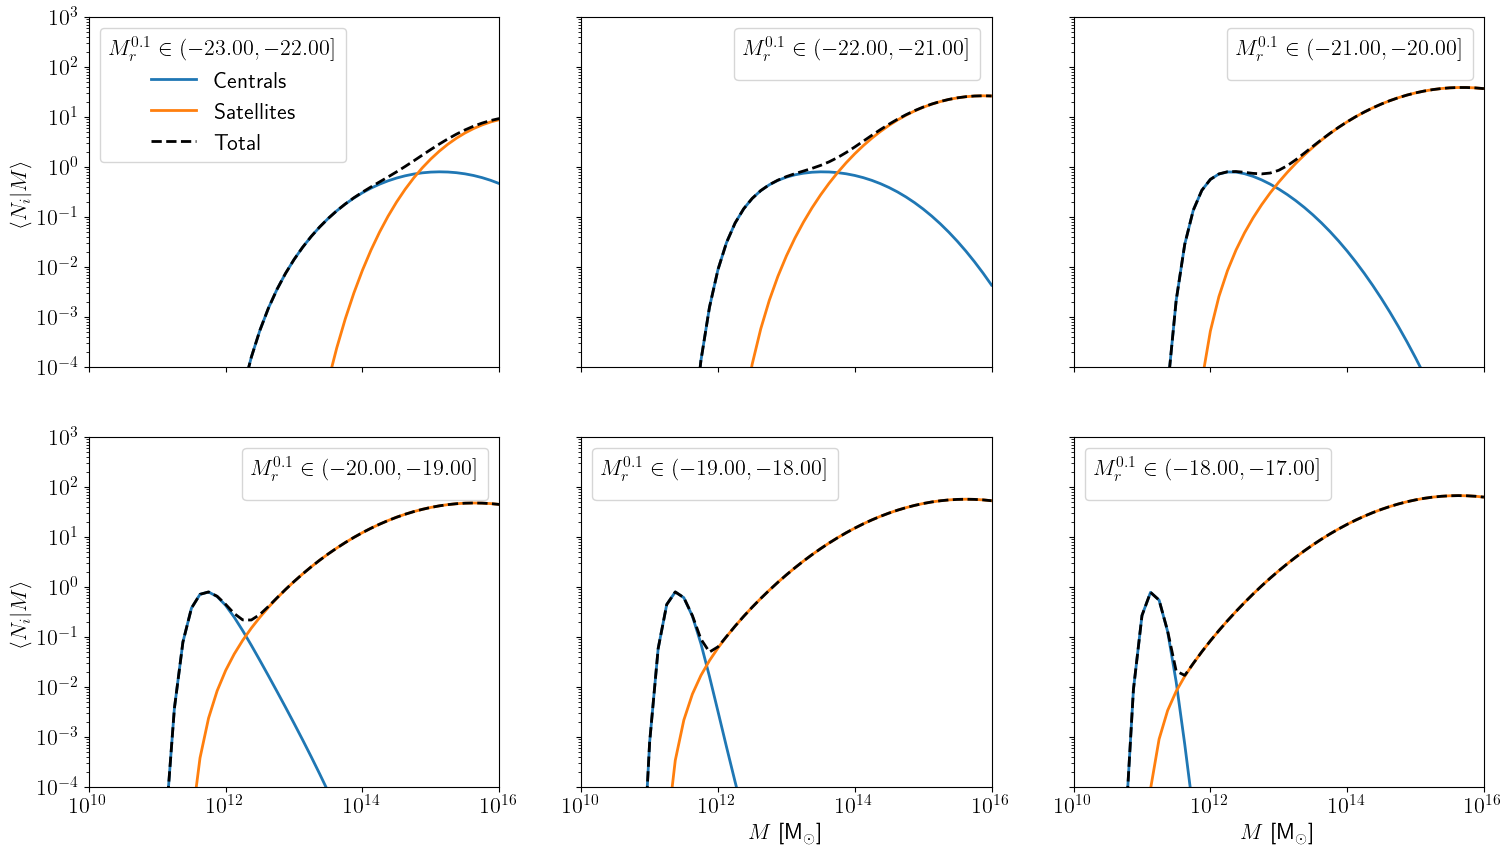

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

for ii, (L2, L1) in enumerate(sampleinfo["mag_bins"]):
    log_L2 = np.log10(magnitude_to_luminosity(L2))  # bright
    log_L1 = np.log10(magnitude_to_luminosity(L1))  # faint
    print(f"luminosity bin for the magnitude bin ({L2}, {L1}]:")
    print(f"{log_L2:<.4e}, {log_L1:<.4e}")

    my_params = dict(log_L1=log_L1, log_L2=log_L2, **cacciato_med_pars)
    hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, **my_params)
    M = np.geomspace(10**8, 10**16, 65)
    Ns = hod._Ns(M)
    Nc = hod._Nc(M)

    info = rf"$M_{{r}}^{{0.1}} \in ({L2:.2f},{L1:.2f}]$"
    ax = axes.flatten()[ii]
    (c,) = ax.loglog(M, Nc, lw=2, label="_")
    (s,) = ax.loglog(M, Ns, lw=2, label="_")
    (t,) = ax.loglog(M, Nc + Ns, "--", c="k", lw=2, label="_")
    if ii == 0:
        ax.plot([], [], color=c.get_color(), lw=2, label="Centrals")
        ax.plot([], [], color=s.get_color(), lw=2, label="Satellites")
        ax.plot([], [], "--", color=t.get_color(), lw=2, label="Total")
        ax.legend(title=info)
    else:
        ax.legend(title=info)
    if ii in [4, 5]:
        ax.set_xlabel(r"$M$ [M$_\odot$]")
    if ii in [0, 3]:
        ax.set_ylabel(r"$\langle N_i|M \rangle$")
    ax.set_ylim(1e-4, 1e3)
    ax.set_xlim(1e10, 1e16)
# plt.savefig("Cacciato_HOD_Nc_Ns_vs_M_all_bins.pdf", bbox_inches='tight', dpi=200)
plt.show()

### Make an HOD plot that is verified against some published work or a working code

<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_959148/2276955432.py:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax.set_xlabel('$M$ [M$_\odot$]')


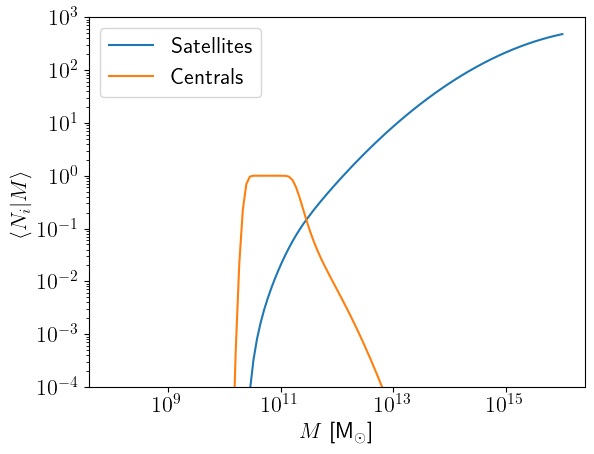

In [ ]:
# # Christos's plot used some arbitrary values of luminosities (which ended up being a broader luminosity bin than mine/Cacciato's)
# # and artificially modified the satellite parameters, So the shape comes out to be strange. So don't worry about this difference.
# fig, ax = plt.subplots()
# ax.loglog(mass_arr, Ns, label="Satellites")
# ax.loglog(mass_arr, Nc, label="Centrals")
# ax.set_ylim([1e-4, 1e3])
# ax.legend()
# ax.set_xlabel("$M$ [M$_\odot$]")
# ax.set_ylabel(r"$\langle N_i|M \rangle$")
# plt.savefig("Cacciato_HOD_Nc_Ns_vs_M.pdf", bbox_inches="tight", dpi=200)

My explorations with CCL

In [30]:
from pyccl.halos.halo_model import HMCalculator
from pyccl.halos.massdef import MassDef
from pyccl.halos.concentration import ConcentrationDuffy08

mass_function = ccl.halos.MassFuncTinker08(mass_def=hmd_200m)
halo_bias = ccl.halos.HaloBiasTinker10(mass_def=hmd_200m)
hmcalc = HMCalculator(
    mass_function=mass_function, halo_bias=halo_bias, mass_def=hmd_200m
)


In [31]:
hmcalc.integrate_over_massfunc?

Signature: hmcalc.integrate_over_massfunc(func, cosmo, a)
Docstring:
Returns the integral over mass of a given funcion times
the mass function:

.. math::
    \int dM\,n(M,a)\,f(M)

Args:
    func (:obj:`callable`): a function accepting an array of halo masses
        as a single argument, and returning an array of the
        same size.
    cosmo (:class:`~pyccl.cosmology.Cosmology`): a Cosmology object.
    a (:obj:`float`): scale factor.

Returns:
    :obj:`float`: integral value.
File:      /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/halo_model.py
Type:      method

# TO DOs 
- Correct the units in the following plot
- Make sure you're using correct c-M relation and the halo mass-function as Cacciato et al. 2013
- Note, that each of the dots are computed at the redshift of the sample, so you can try to match this with the computed $\Phi(L)$ of Cacciato et al.

In [ ]:
log_lum_bin_centers = np.empty(len(sampleinfo["mag_bins"]))
phi_L_cen = np.empty_like(lum_bin_centers)
phi_L_sat = np.empty_like(lum_bin_centers)
redshifts = np.empty_like(lum_bin_centers)

for ii, (L2, L1) in enumerate(sampleinfo["mag_bins"]):
    log_L2 = np.log10(magnitude_to_luminosity(L2))  # bright
    log_L1 = np.log10(magnitude_to_luminosity(L1))  # faint
    print(f"luminosity bin for the magnitude bin ({L2}, {L1}]:")
    print(f"{log_L2:<.4e}, {log_L1:<.4e}")

    log_lum_bin_centers[ii] = 0.5 * (log_L1 + log_L2)
    redshifts[ii] = sampleinfo["zmeans"][ii]

    my_params = dict(log_L1=log_L1, log_L2=log_L2, **cacciato_med_pars)
    temp_hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, **my_params)
    # Integrate over the mass function to get phi(L) for centrals and satellites
    phi_L_cen[ii] = hmcalc.integrate_over_massfunc(
        temp_hod._Nc, cosmo, 1 / (1 + redshifts[ii])
    )
    phi_L_sat[ii] = hmcalc.integrate_over_massfunc(
        temp_hod._Ns, cosmo, 1 / (1 + redshifts[ii])
    )  # check in CCL if passing of same redshift recomputes same cosmology related stuff again?

print(redshifts)
print("Phi_sat =", phi_L_sat)
print("Phi_cen =", phi_L_cen)

luminosity bin for the magnitude bin (-23.0, -22.0]:
1.1104e+01, 1.0704e+01
luminosity bin for the magnitude bin (-22.0, -21.0]:
1.0704e+01, 1.0304e+01
luminosity bin for the magnitude bin (-21.0, -20.0]:
1.0304e+01, 9.9040e+00
luminosity bin for the magnitude bin (-20.0, -19.0]:
9.9040e+00, 9.5040e+00
luminosity bin for the magnitude bin (-19.0, -18.0]:
9.5040e+00, 9.1040e+00
luminosity bin for the magnitude bin (-18.0, -17.0]:
9.1040e+00, 8.7040e+00
[0.021 0.032 0.05  0.082 0.123 0.187]
Phi_sat = [2.22649180e-06 1.17043263e-04 6.67351094e-04 1.33710273e-03
 1.80308591e-03 2.14164846e-03]
Phi_cen = [2.30206591e-05 4.29664908e-04 1.69952163e-03 2.83701097e-03
 3.75246404e-03 4.82285178e-03]


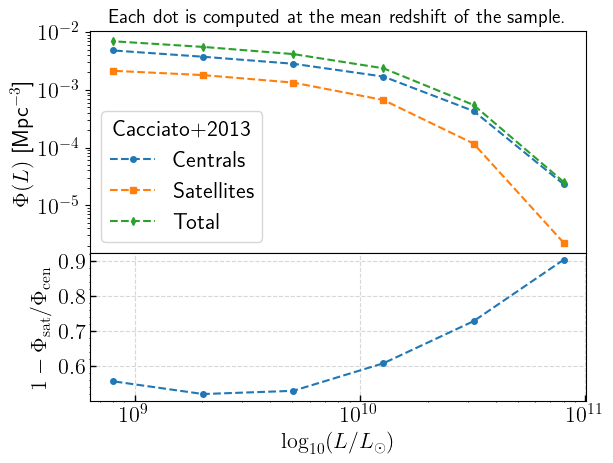

In [ ]:
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

fig, axes = plt.subplots(
    2,
    1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.0},
)

ax = axes[0]
ax.loglog(10**log_lum_bin_centers, phi_L_cen, "o--", ms=4, label="Centrals")
ax.loglog(10**log_lum_bin_centers, phi_L_sat, "s--", ms=4, label="Satellites")
ax.loglog(10**log_lum_bin_centers, phi_L_cen + phi_L_sat, "d--", ms=4, label="Total")

# ax.set_xlabel(r"$\log_{10}(L/L_\odot)$")
ax.set_ylabel(r"$\Phi(L)$ [Mpc$^{-3}$]")
ax.legend(title="Cacciato+2013")
ax.set_title(r"Each dot is computed at the mean redshift of the sample.", fontsize=14)

ax = axes[1]
# increase number of major ticks and enable minor ticks on the bottom subplot
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_minor_locator(AutoMinorLocator())
axes[1].tick_params(which="major", length=4, width=1, direction="in")
# make major ticks point inward, remove minor ticks, and enable a major-grid
axes[1].tick_params(which="minor", length=1)
# axes[1].xaxis.set_minor_locator()
# axes[1].yaxis.set_minor_locator()
axes[1].grid(True, which="major", axis="both", linestyle="--", alpha=0.5)

ax.plot(
    10**log_lum_bin_centers,
    1 - phi_L_sat / phi_L_cen,
    "o--",
    ms=4,
    label="Centrals - Satellites",
)
ax.set_xscale("log")
ax.set_xlabel(r"$\log_{10}(L/L_\odot)$")
ax.set_ylabel(r"$1-\Phi_{\rm sat} / \Phi_{\rm cen}$")

# plt.savefig("Cacciato_HOD_phi_L_cen_sat.pdf", bbox_inches='tight', dpi=200)
plt.show()
